# Example of using C++ code in python and Jupyter with pybind11

This notebook demonstrates how to use pybind11. It is directly analogous to the SWIG example at `example_swig_cpp.ipynb`. 

[pybind11](https://pybind11.readthedocs.io) lets you write the python bindings directly in C++. There is no separate "interface-description" language like SWIG's `.i` files, instead using something called "template metaprogramming." You still write a small amount of binding code by hand, and you still need a build step, but pybind11 is header-only, so that build step is a single compiler invocation, with no extra build-system layer required.

Before starting, you should have pybind11 installed. If using pixi, you can add it to your environment with:

```
pixi add pybind11
```

(If you get a strange error about too many files open, you can increase the limit using `uname -n 10000`.)




In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numba


## Step 1: Look at the C++ files

In [2]:
! cat pybind_example/example.h pybind_example/example.cpp


#ifndef EXAMPLE_H
#define EXAMPLE_H

#include <vector>
#include <pybind11/numpy.h>
#include <cstdint>

namespace py = pybind11;

long sum_int(std::vector<long> const & vec);

int64_t sum_int_numpy(py::array_t<int64_t, py::array::c_style | py::array::forcecast> arr);

int sum_int_int(std::vector<int> const & vec);

#endif // EXAMPLE_H
#include "example.h"

long sum_int(std::vector<long> const & vec)
{
  long sum = 0;
  for ( auto i : vec ) {
    sum += i;
  }
  return sum;
}

int64_t sum_int_numpy(py::array_t<int64_t, py::array::c_style | py::array::forcecast> arr) {
    py::buffer_info buf = arr.request();      // inspect the array without copying
    int64_t* ptr = static_cast<int64_t*>(buf.ptr);    // raw pointer straight into numpy's memory
    int64_t sum = 0;
    for (ssize_t i = 0; i < buf.size; i++) {
        sum += ptr[i];
    }
    return sum;
}

int sum_int_int(std::vector<int> const & vec)
{
  int sum = 0;
  for ( auto i : vec ) {
    sum += i;
  }
  return sum;
}


## Step 2: Look at the pybind11 binding file

This replaces SWIG's `example.i` interface file. There is no separate mini-language here — it's ordinary C++, using pybind11's headers.

Notice `#include <pybind11/stl.h>`: this pulls in automatic conversions between `std::vector` and python lists, which is the pybind11 equivalent of SWIG's `%include "std_vector.i"` + `%template(vector_int) vector<int>;` lines. You don't need a named wrapper type like SWIG's `vector_int` — a plain python list converts automatically.


In [3]:
! cat pybind_example/binding.cpp


#include <pybind11/pybind11.h>
#include <pybind11/stl.h>  // enables automatic std::vector <-> python list conversion
#include <pybind11/stl_bind.h> // For py::bind_vector
#include "example.h"

namespace py = pybind11;

PYBIND11_MAKE_OPAQUE(std::vector<long>);

PYBIND11_MODULE(example_pybind11, m) {
  m.doc() = "Simple pybind11 example (mirrors the SWIG example)";

  m.def("sum_int", &sum_int, "Sum a vector of ints",
        py::arg("vec"));

  m.def("sum_int_numpy", &sum_int_numpy, "Sum a numpy array of ints");

  m.def("sum_int_int", &sum_int_int, "Sum a vector of ints",
        py::arg("vec"));

  py::bind_vector<std::vector<long>>(m, "VectorLong"); // Make vector<int> available in python, as VectorInt

  py::bind_vector<std::vector<int>>(m, "VectorInt"); // Make vector<int> available in python, as VectorInt
}


## Step 3: Compile

With SWIG, this took **two** commands: one to generate `example_wrap.cxx` from the `.i` file (`swig -c++ -python ...`), then one to actually compile everything (`python setup.py build_ext --inplace`).

pybind11 is header-only: there's no code to generate and no build-system layer needed. Compiling is a single call to your C++ compiler, as shown in the [pybind11 docs](https://pybind11.readthedocs.io/en/stable/basics.html#compiling-the-test-cases). It needs two small pieces of help from the `pybind11` python package: `python3 -m pybind11 --includes` (where its headers live) and `python3 -m pybind11 --extension-suffix` (the correct filename ending for your python installation).

**Warning**

The build command is different for MacOS and Linux. Linux uses `-fPIC`, while MacOS uses `-undefined dynamic_lookup`. The cell below picks the right one automatically using the `uname` command.


In [4]:
%%bash
if [[ "$(uname)" == "Darwin" ]]; then
  clang++ -O3 -Wall -shared -undefined dynamic_lookup \
      $(python3 -m pybind11 --includes) \
      pybind_example/binding.cpp pybind_example/example.cpp \
      -o example_pybind11$(python3 -m pybind11 --extension-suffix)
else
  g++ -O3 -Wall -shared -fPIC \
      $(python3 -m pybind11 --includes) \
      pybind_example/binding.cpp pybind_example/example.cpp \
      -o example_pybind11$(python3 -m pybind11 --extension-suffix)
fi


## Step 4: Make profit

If you look in the left sidebar, a new file has appeared! The product of your hard work to create a new python module. We can 


With pybind11, the compiled extension module *is* `example` — there's no separate `.py` wrapper file, and it just got built right here next to this notebook. So we can just import it directly:


With SWIG, `import example` loaded a generated `example.py` wrapper module (which lived inside `swig_example/`), so you had to add that folder to `sys.path` first.


In [5]:
import example_pybind11
help(example_pybind11)


Help on module example_pybind11:

NAME
    example_pybind11 - Simple pybind11 example (mirrors the SWIG example)

CLASSES
    pybind11_builtins.pybind11_object(builtins.object)
        VectorInt
        VectorLong

    class VectorInt(pybind11_builtins.pybind11_object)
     |  Method resolution order:
     |      VectorInt
     |      pybind11_builtins.pybind11_object
     |      builtins.object
     |
     |  Methods defined here:
     |
     |  __bool__(...)
     |      __bool__(self: collections.abc.Sequence[typing.SupportsInt | typing.SupportsIndex]) -> bool
     |
     |      Check whether the list is nonempty
     |
     |  __contains__(...)
     |      __contains__(self: collections.abc.Sequence[typing.SupportsInt | typing.SupportsIndex], x: typing.SupportsInt | typing.SupportsIndex) -> bool
     |
     |      Return true the container contains ``x``
     |
     |  __delitem__(...)
     |      __delitem__(*args, **kwargs)
     |      Overloaded function.
     |
     |      1. __

And finally, we can use our code.


In [6]:
x = example_pybind11.sum_int(
    example_pybind11.VectorLong([1, 2, 3]))
print(x)

x = example_pybind11.sum_int_numpy(np.array([1, 2, 3]))
print(x)

x = example_pybind11.sum_int_int([1, 2, 3])
print(x)


6
6
6


# Success!
Now let's compare with bare python, numba, and numpy.


In [7]:
import numba
import numpy as np

def sum_int_py(arr):
    total = 0
    for x in arr:
        total += x
    return total

@numba.jit(nopython=True)
def sum_int_numba(arr):
    total = 0
    for x in arr:
        total += x
    return total
sum_int_py([0, 1, 2, 3]) # Run it once to force compilation


6

In [9]:
arr_np = np.arange(1_000_000)
print("Bare python:")
%timeit sum_int_py(arr_np)

print("numpy built-in:")
%timeit np.sum(arr_np)

print("numba:")
%timeit sum_int_numba(arr_np)

arr_vec = example_pybind11.VectorLong(range(1_000_000))
print("pybind11 (vector long):")
%timeit example_pybind11.sum_int(arr_vec)

print("pybind11 (numpy array):")
%timeit example_pybind11.sum_int_numpy(arr_np)



Bare python:
30.7 ms ± 347 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
numpy built-in:
73.2 μs ± 464 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
numba:
248 μs ± 1.29 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
pybind11 (vector long):
72.6 μs ± 830 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
pybind11 (numpy array):
73.2 μs ± 283 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
pybind11 (vector int):
32.1 ms ± 302 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [11]:
# Finally, map out the performance to inspect the overhead
xx = np.array([10**i for i in range(8)])
#xx = [1_000, 10_000, 100_000, 120_000, 140_000, 160_000, 180_000, 200_000, 300_000, 1_000_000]
t_py = np.zeros_like(xx, dtype=float)
dt_py = np.zeros_like(xx, dtype=float)
t_numba = np.zeros_like(xx, dtype=float)
dt_numba = np.zeros_like(xx, dtype=float)
t_numpy = np.zeros_like(xx, dtype=float)
dt_numpy = np.zeros_like(xx, dtype=float)
t_pybind = np.zeros_like(xx, dtype=float)
dt_pybind = np.zeros_like(xx, dtype=float)
t_pybind_numpy = np.zeros_like(xx, dtype=float)
dt_pybind_numpy = np.zeros_like(xx, dtype=float)

for i in range(len(xx)):
    print(f"\nTest length {xx[i]}")
    print("Bare python")
    arr_np = np.arange(xx[i])
    result_py = %timeit -o sum_int_py(arr_np)
    t_py[i] = result_py.average
    dt_py[i] = result_py.stdev

    print("Numba")
    result_numba = %timeit -o sum_int_numba(arr_np)
    t_numba[i] = result_numba.average
    dt_numba[i] = result_numba.stdev

    print("Numpy")
    result_numpy = %timeit -o np.sum(arr_np)
    t_numpy[i] = result_numpy.average
    dt_numpy[i] = result_numpy.stdev

    print("pybind11 (vector)")
    arr_vec = example_pybind11.VectorLong(range(xx[i]))
    result_pybind = %timeit -o example_pybind11.sum_int(arr_vec)
    t_pybind[i] = result_pybind.average
    dt_pybind[i] = result_pybind.stdev

    print("pybind11 (numpy array)")
    result_pybind_numpy = %timeit -o example_pybind11.sum_int_numpy(arr_np)
    t_pybind_numpy[i] = result_pybind_numpy.average
    dt_pybind_numpy[i] = result_pybind_numpy.stdev



Test length 1
Bare python
236 ns ± 3.5 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
Numba
57.1 ns ± 0.276 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)
Numpy
584 ns ± 5.23 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
pybind11 (vector)
35.5 ns ± 0.195 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)
pybind11 (numpy array)
232 ns ± 2.02 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)

Test length 10
Bare python
525 ns ± 9.65 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
Numba
60.5 ns ± 0.477 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)
Numpy
588 ns ± 4.62 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
pybind11 (vector)
36.5 ns ± 0.221 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)
pybind11 (numpy array)
239 ns ± 1.68 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)

Test length 100
Bare python
3.42 μs ± 56.5 ns per loop (m

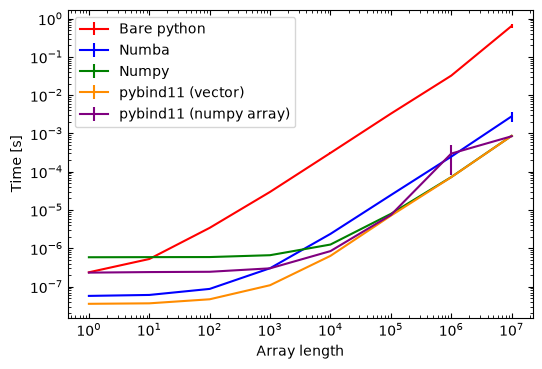

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.errorbar(xx, t_py, yerr=dt_py, color="red", label="Bare python")
ax.errorbar(xx, t_numba, yerr=dt_numba, color="blue", label="Numba")
ax.errorbar(xx, t_numpy, yerr=dt_numpy, color="green", label="Numpy")
ax.errorbar(xx, t_pybind, yerr=dt_pybind, color="darkorange", label="pybind11 (vector)")
ax.errorbar(xx, t_pybind_numpy, yerr=dt_pybind_numpy, color="purple", label="pybind11 (numpy array)")
ax.set_xlabel("Array length")
ax.set_xscale("log")
ax.set_ylabel("Time [s]")
ax.set_yscale("log")
ax.tick_params(which='both', direction="in", top=True, bottom=True, left=True, right=True)
ax.legend(loc="upper left")
fig.savefig("perf_pybind.svg")

## Note: `std::vector<int>` overflow

`sum_int` returns a plain C++ `int`. Summing a million elements overflows a 32-bit `int` and silently wraps around — this isn't a pybind11 (or SWIG) quirk, it's just what the underlying C++ code does. Try `example_pybind11.sum_int(list(range(1_000_000)))` and compare to `np.sum(np.arange(1_000_000))` to see it.
